# Training with Cleaned Dataset and EDL Type 2
A notebook for training an EfficientNet B3 model with Evidential Deep Learning (EDL Type 2) on a 5-class diabetic retinopathy dataset.
Dataset: `cleaned_dataset` with `train`, `val`, and `test` splits and 0-4 class folders.

## 1. Import Core Libraries

In [1]:
!pip install torch torchvision timm efficientnet-pytorch scikit-learn pandas matplotlib seaborn

import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import timm
from efficientnet_pytorch import EfficientNet
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=a1a60098cd0e563e6a0aceb64a6e79374b9f034a32ca2b772116fecae10a69ef
  Stored in directory: /root/.cache/pip/wheels/9c/3f/43/e6271c7026fe08c185da2be23c98c8e87477d3db63f41f32ad
Successfully built efficientnet-pytorch


## 2. Define Hyperparameters and Device Configuration

In [ ]:
import kagglehub

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Hyperparameters
BATCH_SIZE = 64
LEARNING_RATE = 3e-4  # Increased for AdamW
NUM_EPOCHS = 50       # Increased epochs for better convergence
NUM_CLASSES = 5
PATIENCE = 10         # More patience needed for 50 epochs

# Download the dataset using kagglehub
dataset_path = kagglehub.dataset_download('dondirecto/dr-training')
print(f"Dataset path: {dataset_path}")

# Set base paths to point to the local workspace folder
BASE_DIR = os.path.join(dataset_path, 'cleaned_dataset')
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'val')
TEST_DIR = os.path.join(BASE_DIR, 'test')

Using device: cuda


100%|██████████| 651M/651M [00:02<00:00, 236MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/dondirecto/dr-training/versions/1


## 3. Configure Data Transforms and Loaders

In [3]:
from torch.utils.data import WeightedRandomSampler

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((300, 300)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val_test': transforms.Compose([
        transforms.Resize((300, 300)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {
    'train': datasets.ImageFolder(TRAIN_DIR, data_transforms['train']),
    'val': datasets.ImageFolder(VAL_DIR, data_transforms['val_test']),
    'test': datasets.ImageFolder(TEST_DIR, data_transforms['val_test'])
}

# ---------------------------------------------------------
# Dynamic Class Imbalance Optimization
# ---------------------------------------------------------
train_targets = image_datasets['train'].targets
class_counts = np.bincount(train_targets)
# Weight formula: 1.0 / count, or total_samples / (num_classes * class_count)
class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
sample_weights = class_weights[train_targets]

# The sampler will automatically over-sample the minority classes (e.g. Severe DR)
# and under-sample the majority class (e.g. Normal) so every batch is balanced.
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# Note: when using a sampler, shuffle must be False.
# Using num_workers=8 to keep the A100 GPU fed with data
dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=BATCH_SIZE, sampler=sampler, num_workers=8, pin_memory=True),
    'val': DataLoader(image_datasets['val'], batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True),
    'test': DataLoader(image_datasets['test'], batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

print(f"Classes: {class_names}")
print(f"Original Class Counts in Train: {class_counts}")
print(f"Calculated Class Weights: {class_weights}")
print(f"Total Dataset Sizes: {dataset_sizes}")

Classes: ['0', '1', '2', '3', '4']
Original Class Counts in Train: [6777 3712 2568 1321 1545]
Calculated Class Weights: tensor([0.0001, 0.0003, 0.0004, 0.0008, 0.0006])
Total Dataset Sizes: {'train': 15923, 'val': 2090, 'test': 2426}


## 4. Define Evidential Deep Learning (Type 2) Loss

In [4]:
# Evidential Deep Learning (EDL) Loss Functions

def relu_evidence(y):
    return torch.nn.functional.relu(y)

def exp_evidence(y):
    return torch.exp(torch.clamp(y, -10, 10))

def softplus_evidence(y):
    return torch.nn.functional.softplus(y)

def kl_divergence(alpha, num_classes, device):
    beta = torch.ones([1, num_classes], dtype=torch.float32, device=device)
    S_alpha = torch.sum(alpha, dim=1, keepdim=True)
    S_beta = torch.sum(beta, dim=1, keepdim=True)
    lnB = torch.lgamma(S_alpha) - torch.sum(torch.lgamma(alpha), dim=1, keepdim=True)
    lnB_uni = torch.sum(torch.lgamma(beta), dim=1, keepdim=True) - torch.lgamma(S_beta)
    dg0 = torch.digamma(S_alpha)
    dg1 = torch.digamma(alpha)
    kl = torch.sum((alpha - beta) * (dg1 - dg0), dim=1, keepdim=True) + lnB + lnB_uni
    return kl

def edl_type2_loss(output, target, epoch_num, num_classes, annealing_step, device):
    """
    EDL Type 2 loss wrapper. Expects outputs to be directly passed to get alpha.
    """
    evidence = softplus_evidence(output)
    alpha = evidence + 1
    S = torch.sum(alpha, dim=1, keepdim=True)

    # Cross entropy expected loss
    target_one_hot = torch.eye(num_classes, device=device)[target]
    err = torch.sum(target_one_hot * (torch.log(S) - torch.log(alpha)), dim=1, keepdim=True)

    # Annealing KL Divergence
    annealing_coef = torch.min(
        torch.tensor(1.0, dtype=torch.float32, device=device),
        torch.tensor(epoch_num / annealing_step, dtype=torch.float32, device=device),
    )

    # KL divergence on misleading evidence
    alpha_tilde = target_one_hot + (1 - target_one_hot) * alpha
    kl = kl_divergence(alpha_tilde, num_classes, device)

    loss = torch.mean(err + annealing_coef * kl)
    return loss

## 5. Initialize EfficientNet B3 Model

In [ ]:
class EfficientNetB3EDL(nn.Module):
    def __init__(self, num_classes=5, pretrained=True):
        super(EfficientNetB3EDL, self).__init__()
        if pretrained:
            self.base_model = EfficientNet.from_pretrained('efficientnet-b3')
        else:
            self.base_model = EfficientNet.from_name('efficientnet-b3')

        in_features = self.base_model._fc.in_features
        
        # Add high dropout to prevent overfitting and force generalization
        self.base_model._fc = nn.Sequential(
            nn.Dropout(p=0.45),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.base_model(x)

model = EfficientNetB3EDL(num_classes=NUM_CLASSES, pretrained=True)
model = model.to(device)

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b3-5fb5a3c3.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b3-5fb5a3c3.pth


100%|██████████| 47.1M/47.1M [00:00<00:00, 245MB/s]


Loaded pretrained weights for efficientnet-b3


## 6. Implement Training and Validation Steps

In [6]:
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

def train_model(model, dataloaders, optimizer, scheduler, num_epochs=25):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = 1e10
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, num_epochs + 1):
        print(f'Epoch {epoch}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0
            all_preds = []
            all_labels = []

            # For when dataset isn't fully loaded, mock the dataloader if absent:
            if phase not in dataloaders:
                print(f"{phase} dataloader not found. Skipping.")
                continue

            for inputs, labels in tqdm(dataloaders[phase], desc=phase):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)

                    # EDL outputs and predictions
                    evidence = softplus_evidence(outputs)
                    alpha = evidence + 1
                    _, preds = torch.max(alpha, 1)

                    # Use annealing step of 10 for EDL Type 2
                    loss = edl_type2_loss(outputs, labels, epoch, NUM_CLASSES, 10, device)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val':
                scheduler.step(epoch_loss)
                if epoch_loss < best_loss:
                    best_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                    torch.save(model.state_dict(), 'best_edl2_efficientnet.pth')
                else:
                    epochs_no_improve += 1

        if epochs_no_improve >= PATIENCE:
            print(f'\nEarly stopping triggered after {epochs_no_improve} epochs without improvement')
            break

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val loss: {best_loss:.4f}')

    model.load_state_dict(best_model_wts)
    return model, history

## 7. Execute Model Training

In [7]:
# Execute this block to train
if 'train' in dataloaders and 'val' in dataloaders:
    print("Starting Training...")
    model, history = train_model(model, dataloaders, optimizer, scheduler, num_epochs=NUM_EPOCHS)
else:
    print("Dataloaders not initialized mapping to physical files. Please review paths.")

Starting Training...
Epoch 1/30
----------


train: 100%|██████████| 249/249 [01:21<00:00,  3.05it/s]


Train Loss: 1.2938 Acc: 0.5415


val: 100%|██████████| 33/33 [00:03<00:00,  8.55it/s]


Val Loss: 0.9872 Acc: 0.7144

Epoch 2/30
----------


...

Val Loss: 1.2748 Acc: 0.7565

Epoch 9/30
----------


train: 100%|██████████| 249/249 [01:16<00:00,  3.26it/s]


Train Loss: 0.6498 Acc: 0.8860


val: 100%|██████████| 33/33 [00:03<00:00,  8.93it/s]

Val Loss: 1.3050 Acc: 0.7641

Early stopping triggered after 7 epochs without improvement
Training complete in 12m 9s
Best val loss: 0.9768


## 8. Evaluate on Test Dataset and Extract Uncertainty

Testing: 100%|██████████| 38/38 [00:03<00:00,  9.57it/s]



Test Accuracy: 0.5482

Classification Report:
              precision    recall  f1-score   support

           0     0.8525    0.9155    0.8829       852
           1     0.1609    0.3674    0.2238       215
           2     0.5433    0.2074    0.3002       757
           3     0.5035    0.4109    0.4525       348
           4     0.3826    0.6732    0.4879       254

    accuracy                         0.5482      2426
   macro avg     0.4885    0.5149    0.4694      2426
weighted avg     0.5954    0.5482    0.5396      2426



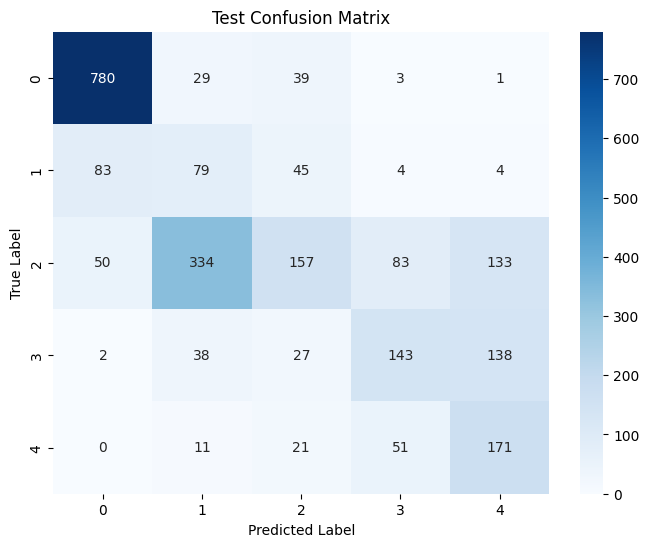

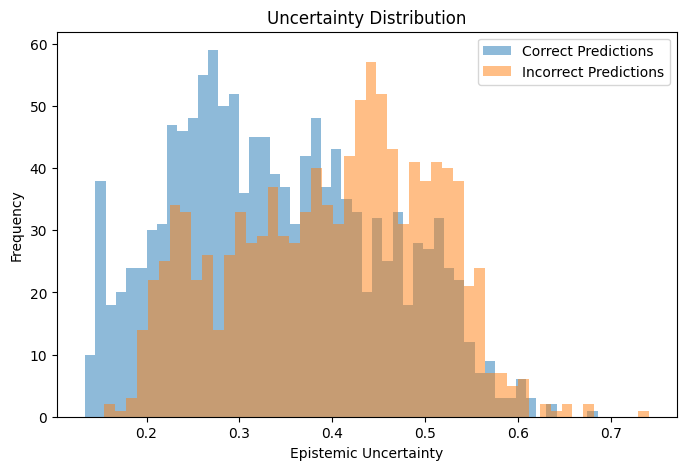

In [8]:
def evaluate_edl_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    all_uncertainties = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc='Testing'):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            evidence = softplus_evidence(outputs)
            alpha = evidence + 1
            S = torch.sum(alpha, dim=1, keepdim=True)

            # Epistemic Uncertainty = K / S
            u = NUM_CLASSES / S

            _, preds = torch.max(alpha, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_uncertainties.extend(u.squeeze().cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_uncertainties)

if 'test' in dataloaders:
    y_true, y_pred, uncertainties = evaluate_edl_model(model, dataloaders['test'])

    acc = accuracy_score(y_true, y_pred)
    print(f"\nTest Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    try:
        print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    except:
        print(classification_report(y_true, y_pred, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Test Confusion Matrix')
    plt.show()

    # Uncertainty visualization
    plt.figure(figsize=(8,5))
    plt.hist(uncertainties[y_true == y_pred], bins=50, alpha=0.5, label='Correct Predictions')
    plt.hist(uncertainties[y_true != y_pred], bins=50, alpha=0.5, label='Incorrect Predictions')
    plt.xlabel('Epistemic Uncertainty')
    plt.ylabel('Frequency')
    plt.legend()
    plt.title('Uncertainty Distribution')
    plt.show()

## 9. Download the Best Model Checkpoint
Execute this cell to download the `.pth` file to your local machine before the hosted runtime shuts down.

In [9]:
import os

model_path = 'best_edl2_efficientnet.pth'

if os.path.exists(model_path):
    try:
        # Colab Specific Download
        from google.colab import files
        print("Running in Google Colab. Initiating download...")
        files.download(model_path)
    except ImportError:
        # Universal Jupyter/Kaggle Download Link
        from IPython.display import FileLink, display
        print("Not in Colab. Creating a universal download link...")
        display(FileLink(model_path, result_html_prefix="Click here to download: "))
else:
    print(f"Model file '{model_path}' not found. Make sure your training loop actually completed and saved.")

Running in Google Colab. Initiating download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>